# Support Vector Machine

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chattopadhyayA/ml_for_physics/blob/master/content_nb/04_svm.ipynb)

As you can see from the previous example of decision trees, for classification we are basically after a **decision boundary**. If we can find a good boundary separating one class from another, then we can classify new points by checking which side of the boundary they fall on. Support Vector Machines, or **SVMs**, are one of the cleanest machine learning methods built around exactly this idea.

The core idea of SVM is:

```{admonition} Main idea
:class: important

Find the decision boundary that separates the classes with the **largest possible margin**.

In other words, SVM does not only ask:

"Can I separate the two classes?"

It asks:

"Can I separate the two classes as safely as possible?"
```

```{figure} images/svm.png
---
height: 300px
name:   svm
align:  center
---
"svm"
```
## <span style="color:maroon"> Buzz words </span>

**Hyperplane:**  
This is the decision boundary. In two dimensions it is a line. In three dimensions it is a plane. In higher dimensions it is called a hyperplane.

Mathematically, a linear decision boundary can be written as

$$
\omega \cdot x + b = 0.
$$

Here, $x$ is the input feature vector, $\omega$ controls the orientation of the boundary, and $b$ shifts the boundary.

**Support vectors:**  
Support vectors are the data points closest to the hyperplane. These points are the most important points for constructing the classifier.

**Margin:**  
The margin is the distance between the decision boundary and the closest points from the two classes. SVM tries to make this margin as large as possible.

```{admonition} Physical intuition
:class: tip

Think of the decision boundary as a wall separating two groups.

Many walls may separate the two groups, but SVM chooses the wall that leaves the largest empty space on both sides.

This makes the classifier more stable against small changes in the data.
```


Although the basic SVM picture is easiest to understand for two classes, SVMs can also be used for multi-class classification. In practice, a multi-class SVM is usually built by combining several binary SVM classifiers, for example using one-vs-rest or one-vs-one strategies. Thus, the hyperplane idea remains the basic building block, but several such decision boundaries may be combined to classify more than two groups.

## <span style="color:maroon"> Working principle </span>

Let us write the two class labels as

$$
y_i \in \{-1,+1\}.
$$

For a linear SVM, the decision boundary is

$$
\omega\cdot x + b = 0.
$$

This is the middle boundary, where the classifier is exactly undecided.

A point is classified by checking the sign of this quantity:

$$
\text{sign}(\omega\cdot x+b).
$$

So:

- if $\omega\cdot x+b > 0$, the model predicts class $+1$;
- if $\omega\cdot x+b < 0$, the model predicts class $-1$.

SVM also introduces two margin boundaries:

$$
\omega\cdot x+b=1
$$

and

$$
\omega\cdot x+b=-1.
$$

The closest points from the two classes lie on these margin boundaries. These closest points are called support vectors.

For a perfectly separable dataset, SVM imposes the condition

$$
y_i(\omega\cdot x_i+b)\geq 1.
$$

This compact condition means:

$$
\omega\cdot x_i+b\geq 1
\qquad
\text{for } y_i=+1,
$$

and

$$
\omega\cdot x_i+b\leq -1
\qquad
\text{for } y_i=-1.
$$

So every point should lie on the correct side of the margin, not just the correct side of the middle decision boundary.

The margin width turns out to be

$$
\frac{2}{||\omega||}.
$$

Therefore, maximizing the margin is equivalent to minimizing $||\omega||$.



### ❓ Exercise

**Q1:** Suppose a data point has label $y_i=+1$ and the model gives

$$
\omega\cdot x_i+b=0.6.
$$

Is this point correctly classified? Does it satisfy the SVM margin condition?


```{dropdown} Click to show answer

The point is correctly classified because

$$
\omega\cdot x_i+b=0.6>0.
$$

So the model predicts class $+1$.

However, it does not satisfy the SVM margin condition, because for $y_i=+1$ we need

$$
\omega\cdot x_i+b\geq 1.
$$

Here,

$$
0.6<1.
$$

So the point is on the correct side of the decision boundary, but it lies inside the margin.
```



## <span style="color:maroon"> Flowchart </span>

Without going into intricacies, the flowchart of SVM can be summarised as 

1. **Assume a Linear Separator:**: SVM tries to find a hyperplane $\omega\cdot x+b=0$, that separates the data into two classes.

2. **Maximize the Margin**: Rather than checking all possible planes, SVM optimizes for the one that maximizes the margin — the distance between the hyperplane and the closest points from each class, called support vectors.


$$
Margin=\frac{2}{||\omega||}
$$

3. **Optimization Problem**: Minimise 

$$ \frac{1}{2}||\omega||^2 $$

subject to $y_i(\omega x_i+b)\geq 1$, with $y_i$ being the label of the class. This is a quadratic programming problem.

4. **Support Vectors Determine the Plane**: Only data points on the margin boundaries (i.e., support vectors) affect the position of the hyperplane.

5. **Use Kernel Trick (if needed)**: For non-linear data, use a kernel function (e.g., Radial Basis Function (RBF), polynomial) to project data into higher dimensions where it becomes linearly separable. 

To illustrate the kernel trick, let us consider a simple toy dataset about students. Suppose we record each student’s shoe size and whether or not they love soccer. We represent students who love soccer by blue dots, and students who do not love soccer by red dots.

![alt text](images/soccer_shoe.png "Title")

At first, if we look only at shoe size, the two groups may not be cleanly separated by a simple logistic regression model. But if we map the data into a higher-dimensional feature space, for example by adding a new feature such as $\text{shoe size}^2$, the two groups may become easier to separate with a straight line. This is the basic spirit of the SVM kernel trick.

## A small visual helper

Before using SVM, let us define one helper function. This function plots a two-dimensional dataset and draws the decision boundary learned by a classifier.

You do not have to understand every line of this plotting function. The important point is that it lets us see what the model has learned.

In [1]:
# Basic numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.datasets import make_blobs, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def plot_decision_boundary(model, X, y, title="", show_support_vectors=True):
    """
    Plot the decision boundary of a classifier trained on two-dimensional data.
    """
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", s=60)

    if show_support_vectors and hasattr(model, "support_vectors_"):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=180,
            facecolors="none",
            edgecolors="black",
            linewidths=2,
            label="Support vectors"
        )
        plt.legend(loc="best")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

## Example: Linear SVM

Let us first create a toy dataset where the two classes can be separated almost linearly.

This is the simplest situation for SVM.

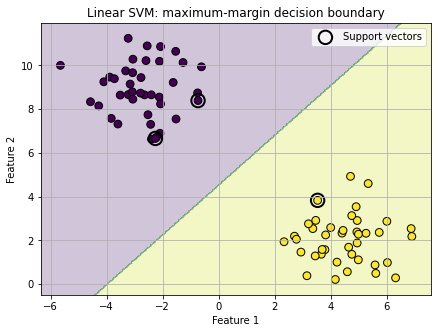

Number of support vectors in each class: [2 1]


In [2]:
X, y = make_blobs(
    n_samples=80,        # Total number of data points
    centers=2,           # Number of groups/classes to create
    cluster_std=1.2,     # Spread of each cluster; larger value means more overlap
    random_state=RANDOM_STATE  # Fixes randomness so the result is reproducible
)

# Now we define a linear Support Vector Machine.
# kernel="linear" means the SVM will try to separate the two classes
# using a straight line in 2D.
#
# C is a regularization parameter.
# For now, we keep C=1.0 as a standard/default choice.
# Roughly speaking, it controls how strictly the model tries to classify
# all training points correctly. We will not discuss it in detail here.

linear_svm = SVC(kernel="linear", C=1.0)


# Train the SVM on the generated data.
# The model learns the best separating line by maximizing the margin.

linear_svm.fit(X, y)

# Plot the learned decision boundary.
# The straight line is the SVM decision boundary.
# The points closest to this boundary are the support vectors.

plot_decision_boundary(
    linear_svm,
    X,
    y,
    title="Linear SVM: maximum-margin decision boundary"
)

# n_support_ tells us how many support vectors were used from each class.
# These are the most important points for determining the SVM boundary.

print("Number of support vectors in each class:", linear_svm.n_support_)

## Example: Linear SVM with multiple classes

Let us make the simple situation more complicated by introducing multiple classes. Here we create 4 clusters/classes instead of 2. The basic SVM idea is binary, but sklearn can combine several binary SVMs.

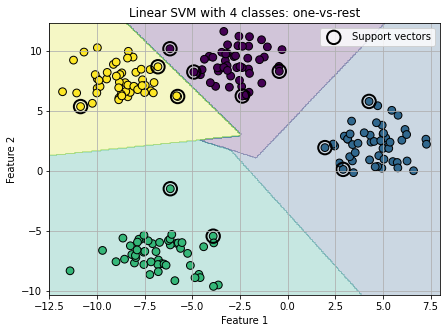

Classes: [0 1 2 3]
Number of support vectors in each class: [4 3 2 3]


In [8]:
X_multi, y_multi = make_blobs(
    n_samples=200,
    centers=4,
    cluster_std=1.4,
    random_state=RANDOM_STATE
)
# decision_function_shape="ovr" means one-vs-rest:
# class 0 vs not class 0, class 1 vs not class 1, and so on.

# decision_function_shape="ovo" means one-vs-one:
# class 0 vs class 1, class 0 vs class 2, class 0 vs class 3,
# class 1 vs class 2, and so on.

# NOTE: In sklearn's SVC, multiclass training is internally handled using one-vs-one.
# The "ovr" option mainly changes the shape of the decision scores.
# Therefore, for simple datasets, the OVR and OVO plots can look the same.


multi_svm_ovr = SVC(
    kernel="linear",
    C=1.0,
    decision_function_shape="ovr"
)

multi_svm_ovr.fit(X_multi, y_multi)

plot_decision_boundary(
    multi_svm_ovr,
    X_multi,
    y_multi,
    title="Linear SVM with 4 classes: one-vs-rest"
)

print("Classes:", multi_svm_ovr.classes_)
print("Number of support vectors in each class:", multi_svm_ovr.n_support_)

## Example: Linear SVM versus RBF-kernel SVM

Let us now use a classic nonlinear toy dataset called the **two moons** dataset.

The two moons dataset contains two interleaving half-circle shaped classes. It is very useful pedagogically because the two classes are clearly separated in a nonlinear way, so a single straight line is not good enough.

Thankfully, `scikit-learn` already provides this dataset through `make_moons`, so we can directly use it for training and visualization.

A straight line is not good enough here. The RBF kernel can do much better.


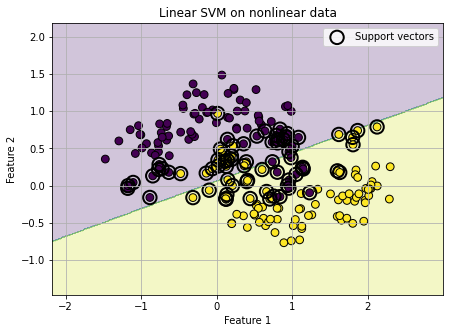

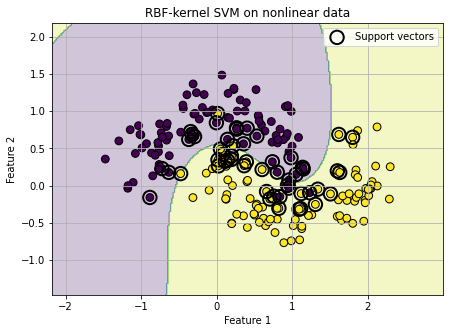

In [9]:
X_moons, y_moons = make_moons(
    n_samples=200,          # Total number of points
    noise=0.20,             # Adds randomness/noise; larger value makes the classes more mixed
    random_state=RANDOM_STATE  # Fixes randomness so we get the same dataset every time
)

# First, train a linear SVM.
# kernel="linear" means the model tries to separate the classes using a straight line.
# This is intentionally too simple for the two moons dataset.

linear_model = SVC(kernel="linear", C=1.0)
linear_model.fit(X_moons, y_moons)

# Now train an RBF-kernel SVM.
# kernel="rbf" allows the SVM to learn a nonlinear decision boundary.
#
# gamma controls how local or flexible the RBF kernel is.
# A large gamma can make the boundary very wiggly.
# A small gamma makes the boundary smoother.
# gamma="scale" is sklearn's default sensible choice, so we use it without discussing it further here.

rbf_model = SVC(kernel="rbf", C=1.0, gamma="scale")
rbf_model.fit(X_moons, y_moons)

# Plot the decision boundary of the linear SVM.
# Since the data are nonlinear, the straight-line boundary will not separate the classes very well.

plot_decision_boundary(
    linear_model,
    X_moons,
    y_moons,
    title="Linear SVM on nonlinear data"
)

# Plot the decision boundary of the RBF-kernel SVM.
# The RBF kernel can bend the decision boundary and follow the two-moons structure much better.

plot_decision_boundary(
    rbf_model,
    X_moons,
    y_moons,
    title="RBF-kernel SVM on nonlinear data"
)

````{admonition} Takeaway: Practical SVM usage with scikit-learn
:class: important

In practice, we usually use SVM through `scikit-learn` by invoking the **Support Vector Classification** or **SVC** module.

```python
from sklearn.svm import SVC
````

For real datasets, the standard workflow is to combine feature scaling and the SVM model inside a `Pipeline`:

```python
StandardScaler()
SVC()
```

This is important because SVMs depend strongly on distances and dot products. If one feature has values around $10^6$ and another feature has values around $1$, the larger-scale feature can dominate the geometry of the classifier.

So the practical rule is:

$$
\boxed{\text{Always scale your data before using SVM.}}
$$

```
```
